# 🎯 Fashion Image Classification - Polyvore Dataset
## Clasificación de imágenes de moda con Deep Learning

**Dataset:** Polyvore (251k items, 11 categorías)

**Objetivo:** Entrenar un modelo de clasificación de imágenes para categorizar productos de moda

---

## ✅ Comprobación de entorno (WSL + GPU)

Esta sección asegura que estás ejecutando el notebook en **WSL** y que TensorFlow ve la **GPU**.


In [1]:
import sys
import os

# Menos ruido de logs
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import tensorflow as tf

print('Python executable:', sys.executable)
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

# Evita que TensorFlow reserve toda la VRAM de golpe
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print('No se pudo activar memory_growth:', e)

# Asegura que hay GPU
assert len(gpus) > 0, '❌ No se detecta GPU. Asegúrate de estar en WSL y con el kernel tf-gpu.'
print('✅ GPU lista')


Python executable: /home/ismael/tf/bin/python
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU lista


In [2]:
# Test rápido en GPU
with tf.device('/GPU:0'):
    a = tf.random.normal([1024, 1024])
    b = tf.random.normal([1024, 1024])
    _ = a @ b
print('✅ Operación en GPU OK')


✅ Operación en GPU OK


I0000 00:00:1771030640.674067    8748 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


## 📦 Instalación de dependencias

In [3]:


# Instalar el resto
! pip install datasets pillow matplotlib scikit-learn seaborn jupyter ipykernel

## 📚 Importación de librerías

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import pickle

from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, metrics
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import mixed_precision

# Configuración
plt.style.use('default')
sns.set_palette('husl')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📊 1. Carga y exploración del dataset

In [6]:
os.environ["HF_HOME"] = "/home/ismael/.cache/huggingface"
os.environ["HF_DATASETS_CACHE"] = "/home/ismael/.cache/huggingface/datasets"
os.environ["HF_METRICS_CACHE"] = "/home/ismael/.cache/huggingface/metrics"
os.environ["HF_HUB_DISABLE_XET"] = "1"


In [10]:
# Cargar dataset desde Kaggle
print("Cargando dataset desde Kaggle...")
dataset = load_dataset("owj0421/polyvore", split="data")

print(f"\n✓ Dataset cargado exitosamente")
print("Columnas:", dataset.features)          # o dataset.column_names si aparece
print("Ejemplo de muestra:", dataset[0])

Cargando dataset desde Kaggle...


data/data-00002-of-00005.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

data/data-00003-of-00005.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/data-00004-of-00005.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/data-00005-of-00005.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

Generating data split: 0 examples [00:00, ? examples/s]


✓ Dataset cargado exitosamente
Columnas: {'item_id': Value('string'), 'image': Image(mode=None, decode=True), 'url_name': Value('string'), 'title': Value('string'), 'description': Value('string'), 'category': Value('string')}
Ejemplo de muestra: {'item_id': '211990161', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=300x300 at 0x7F948A9BFE60>, 'url_name': 'neck print chiffon plus size', 'title': '', 'description': '', 'category': 'tops'}


In [11]:
# Explorar distribución de categorías
df = dataset.select_columns(["image", "category"]).to_pandas()

print("\n📊 Distribución de categorías:\n")
category_counts = df['category'].value_counts()
print(category_counts)

print(f"\nTotal de categorías: {df['category'].nunique()}")
print(f"Total de imágenes: {len(df):,}")


📊 Distribución de categorías:

category
shoes          44850
jewellery      41414
bags           40717
tops           32998
bottoms        27670
all-body       18478
outerwear      17065
sunglasses      9874
accessories     6973
hats            6071
scarves         4898
Name: count, dtype: int64

Total de categorías: 11
Total de imágenes: 251,008


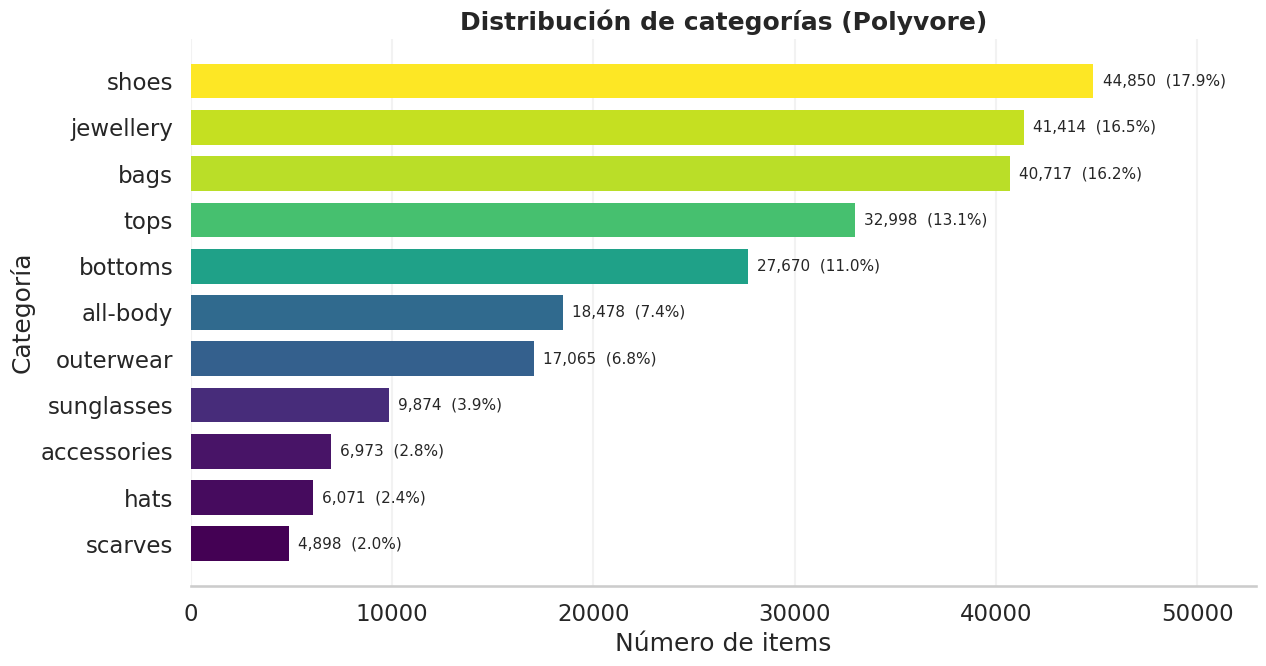

In [ ]:
# Visualizar distribución
# category_counts = df["category"].value_counts()  # (ya lo tienes)
total = category_counts.sum()

# Estilo moderno
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["axes.titleweight"] = "bold"

# Datos
cats = category_counts.index[::-1]          # para barh: menor arriba, mayor abajo (invirtiendo)
vals = category_counts.values[::-1]
pct  = (vals / total) * 100

# Colores 
cmap = sns.color_palette("viridis", as_cmap=True)
norm = plt.Normalize(vals.min(), vals.max())
colors = cmap(norm(vals))

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(cats, vals, color=colors, edgecolor="none", height=0.75)

# Anotar valores + %
for b, v, p in zip(bars, vals, pct):
    ax.text(
        v + max(vals)*0.01,
        b.get_y() + b.get_height()/2,
        f"{v:,}  ({p:.1f}%)",
        va="center",
        ha="left",
        fontsize=11
    )

# Título y etiquetas
ax.set_title("Distribución de categorías (Polyvore)")
ax.set_xlabel("Número de items")
ax.set_ylabel("Categoría")

# Limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Grid suave solo en X
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", alpha=0)

# Ajuste de límites para que quepan anotaciones
ax.set_xlim(0, vals.max() * 1.18)

plt.tight_layout()
plt.show()

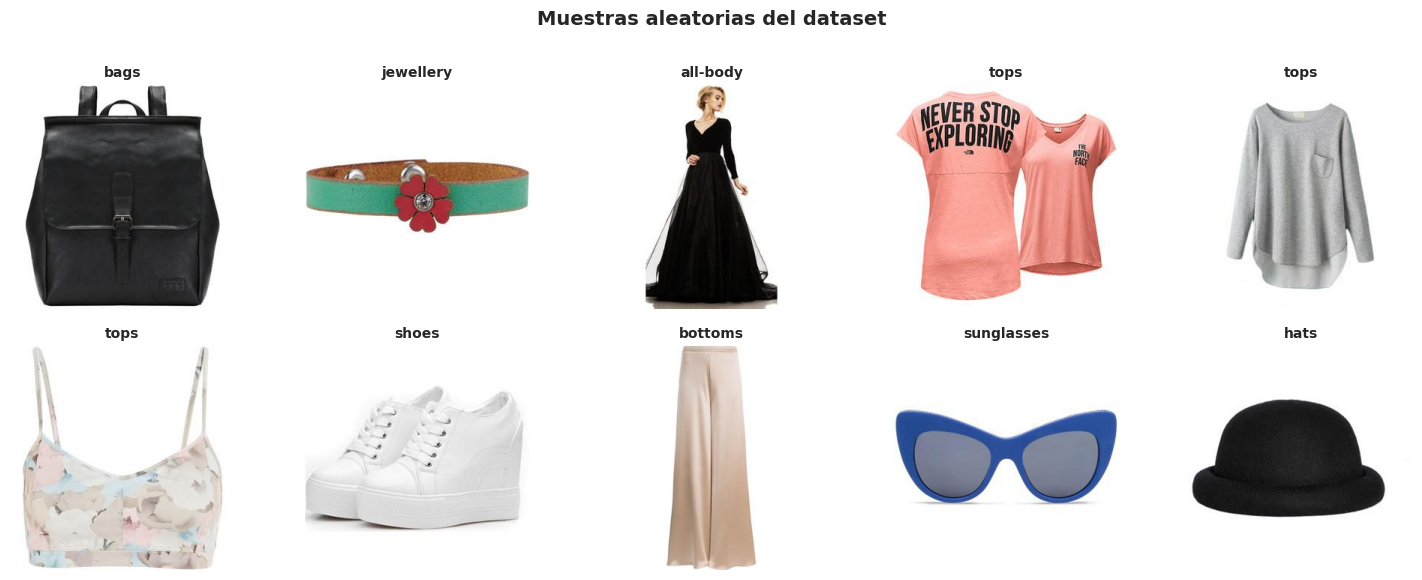

In [23]:
def to_rgb_uint8(img):
    """
    Maneja diccionarios (bytes) y objetos PIL.
    """
    # 1. Si es un diccionario (el error que te salía), extraemos la imagen de los bytes
    if isinstance(img, dict) and 'bytes' in img:
        img = Image.open(io.BytesIO(img['bytes']))

    # 2. Si es (o ya se convirtió en) una imagen PIL, la pasamos a array RGB
    if isinstance(img, Image.Image):
        return np.asarray(img.convert("RGB"), dtype=np.uint8)
    
    # 3. Si ya es un array, nos aseguramos que sea uint8
    return np.asarray(img, dtype=np.uint8)

# --- Visualización ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Muestras aleatorias del dataset", fontsize=14, fontweight="bold")

for ax in axes.flat:
    try:
        sample = df.sample(1).iloc[0]
        # Procesamos
        img_processed = to_rgb_uint8(sample["image"])
        
        ax.imshow(img_processed)
        ax.set_title(sample["category"], fontsize=10)
    except Exception as e:
        ax.text(0.5, 0.5, "Error", ha="center")
        print(f"Error: {e}")
        
    ax.axis("off")

plt.tight_layout()
plt.show()

## 🔧 2. Preprocesamiento de datos

In [ ]:
# Configura política de precisión mixta (float16 para cálculo, float32 para variables)
# Esto acelera el entrenamiento y reduce el uso de VRAM.
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"Policy: {policy.name}")
print(f"Compute dtype: {policy.compute_dtype}")
print(f"Variable dtype: {policy.variable_dtype}")

# Configuración de preprocesamiento
IMG_SIZE = 224  # Tamaño compatible con EfficientNet
BATCH_SIZE = 64 
EPOCHS = 20

print(f"\nConfiguración Optimizada:")
print(f"  - Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE} (Optimizado para GPU)")
print(f"  - Epochs: {EPOCHS}")

Policy: mixed_float16
Compute dtype: float16
Variable dtype: float32

Configuración Optimizada:
  - Tamaño de imagen: 224x224
  - Batch size: 64 (Optimizado para GPU)
  - Epochs: 20


In [27]:
# Codificar categorías
label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['category'])

num_classes = df['category_encoded'].nunique()
print(f"\nNúmero de clases: {num_classes}")
print(f"Rango de etiquetas: {df['category_encoded'].min()} - {df['category_encoded'].max()}")

# Guardar el encoder para uso futuro
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("\n✓ Label encoder guardado")


Número de clases: 11
Rango de etiquetas: 0 - 10

✓ Label encoder guardado


In [ ]:
## Función para preprocesar imágenes
#def preprocess_image(image, target_size=IMG_SIZE):
#    """Preprocesa una imagen PIL al formato requerido"""
#    # Redimensionar
#    img = image.resize((target_size, target_size), Image.Resampling.LANCZOS)
#    # Convertir a array y normalizar
#    img_array = np.array(img, dtype=np.float32) / 255.0
#    # Asegurar 3 canales (RGB)
#    if img_array.ndim == 2:
#        img_array = np.stack([img_array] * 3, axis=-1)
#    elif img_array.shape[-1] == 4:
#        img_array = img_array[..., :3]
#    return img_array
#
#print("Preprocesando imágenes...")
#df['processed_image'] = df['image'].apply(preprocess_image)
#print("✓ Preprocesamiento completado")

In [28]:
# Definimos la función para usarla MÁS ADELANTE (dentro del generador),
# pero NO la aplicamos a todo el dataset ahora.

def preprocess_image(image, target_size=IMG_SIZE):
    """
    Preprocesa una imagen al formato requerido.
    Se usará imagen a imagen durante el entrenamiento, no todas a la vez.
    """
    # Usamos la lógica robusta que arreglamos antes
    img = to_rgb_uint8(image)
    
    # Redimensionar usando TensorFlow (más rápido en GPU luego) o Pillow
    img = tf.image.resize(img, [target_size, target_size])
    
    # Normalizar a [0, 1]
    img = img / 255.0
    
    return img

print("✓ Función 'preprocess_image' definida.")
print("⚠️ IMPORTANTE: No hemos procesado las 250k imágenes todavía para salvar la RAM.")
print("   Se procesarán automáticamente lote por lote al entrenar.")

✓ Función 'preprocess_image' definida.
⚠️ IMPORTANTE: No hemos procesado las 250k imágenes todavía para salvar la RAM.
   Se procesarán automáticamente lote por lote al entrenar.


In [29]:
# Split estratificado: 70% train, 15% val, 15% test
train_idx, temp_idx = train_test_split(
    df.index, 
    test_size=0.3, 
    stratify=df['category_encoded'],
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    stratify=df.loc[temp_idx, 'category_encoded'],
    random_state=42
)

print(f"\n📊 División del dataset:")
print(f"  Train: {len(train_idx):,} ({len(train_idx)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_idx):,} ({len(val_idx)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_idx):,} ({len(test_idx)/len(df)*100:.1f}%)")


📊 División del dataset:
  Train: 175,705 (70.0%)
  Val:   37,651 (15.0%)
  Test:  37,652 (15.0%)


## 🔄 3. Generadores de datos con Data Augmentation

In [30]:
def data_generator(df, indices, batch_size, num_classes, shuffle=True, augment=False):
    """
    Generador optimizado para RTX 3080 + 32GB RAM.
    Realiza carga perezosa (Lazy Loading) y procesamiento al vuelo.
    """
    indices = list(indices)
    num_samples = len(indices)
    
    # Configuración de Data Augmentation
    # Nota: Usamos ImageDataGenerator para transformaciones geométricas simples
    if augment:
        datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.15,
            fill_mode='nearest'
        )
    
    while True:
        if shuffle:
            np.random.shuffle(indices)
        
        for start in range(0, num_samples, batch_size):
            batch_indices = indices[start:start + batch_size]
            batch_data = df.iloc[batch_indices]
            
            X_batch = []
            y_batch = []
            
            # --- BUCLE DE CARGA PEREZOSA (LAZY LOADING) ---
            for _, row in batch_data.iterrows():
                try:
                    # 1. Recuperar imagen cruda y convertir a RGB Array seguro
                    # (Usa la función to_rgb_uint8 que arreglamos antes)
                    img = to_rgb_uint8(row['image'])
                    
                    # 2. Redimensionar (usando TensorFlow es rápido)
                    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
                    
                    # 3. Normalizar a [0, 1]
                    img = img / 255.0
                    
                    X_batch.append(img)
                    y_batch.append(row['category_encoded'])
                except Exception as e:
                    print(f"Error cargando imagen: {e}")
                    # En caso de error, metemos una imagen negra para no romper el batch
                    X_batch.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))
                    y_batch.append(0) # Categoría dummy

            # Convertir listas a arrays de Numpy
            X_batch = np.array(X_batch)
            y_batch = tf.keras.utils.to_categorical(y_batch, num_classes=num_classes)
            
            # --- DATA AUGMENTATION ---
            if augment:
                # Aplicamos transformación a cada imagen del batch
                # (ImageDataGenerator espera input numpy)
                X_batch_aug = np.zeros_like(X_batch)
                for i in range(len(X_batch)):
                    # random_transform espera una imagen [0-255] o [0-1] y devuelve lo mismo
                    X_batch_aug[i] = datagen.random_transform(X_batch[i])
                X_batch = X_batch_aug
            
            yield X_batch, y_batch

# --- CREACIÓN DE GENERADORES ---

# Recalcular steps por si cambiaste BATCH_SIZE a 64
steps_per_epoch = len(train_idx) // BATCH_SIZE
val_steps = len(val_idx) // BATCH_SIZE
test_steps = len(test_idx) // BATCH_SIZE

print(f"Creando generadores con BATCH_SIZE={BATCH_SIZE}...")

train_gen = data_generator(df, train_idx, BATCH_SIZE, num_classes, shuffle=True, augment=True)
val_gen = data_generator(df, val_idx, BATCH_SIZE, num_classes, shuffle=False, augment=False)
test_gen = data_generator(df, test_idx, BATCH_SIZE, num_classes, shuffle=False, augment=False)

print(f"\n✓ Generadores listos para GPU")
print(f"  Steps por epoch: {steps_per_epoch}")
print(f"  Validation steps: {val_steps}")
print(f"  Test steps: {test_steps}")

Creando generadores con BATCH_SIZE=64...

✓ Generadores listos para GPU
  Steps por epoch: 2745
  Validation steps: 588
  Test steps: 588


## 🧠 4. Modelo con Transfer Learning (EfficientNetB0)

In [31]:
# Cargar modelo base preentrenado
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg'
)

# Congelar las capas base inicialmente
base_model.trainable = False

print("✓ Modelo base EfficientNetB0 cargado")

2026-02-14 02:30:54.003380: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ Modelo base EfficientNetB0 cargado


In [33]:
# Construir modelo completo con adaptaciones para precisión mixta y preprocesamiento
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    # 1. ADAPTADOR: Convierte el [0, 1] del generador al [0, 255] que espera EfficientNet
    layers.Rescaling(255.0),
    
    base_model,
    
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    
    # 2. SEGURIDAD MIXED PRECISION: La salida debe ser float32
    # Si no pones esto, la loss se puede ir a NaN
    layers.Dense(num_classes, activation='softmax', dtype='float32')
], name='Fashion_Classifier')

# Compilar
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
)

model.summary()

Model: "Fashion_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,846,766 (18.49 MB)

 Trainable params: 793,611 (3.03 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

## 🏋️ 5. Fase 1: Entrenamiento con capas congeladas

In [34]:
# Callbacks
callbacks_phase1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Iniciando Fase 1: Entrenamiento con capas base congeladas...\n")

Iniciando Fase 1: Entrenamiento con capas base congeladas...



In [35]:
history_phase1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks_phase1,
    verbose=1
)

Epoch 1/10


I0000 00:00:1771032918.607755    8987 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2745/2745 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.8058 - loss: 0.6409 - top_3_accuracy: 0.9459
Epoch 1: val_accuracy improved from None to 0.90556, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 1651s 591ms/step - accuracy: 0.8392 - loss: 0.5113 - top_3_accuracy: 0.9643 - val_accuracy: 0.9056 - val_loss: 0.2943 - val_top_3_accuracy: 0.9856 - learning_rate: 0.0010
Epoch 2/10
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8638 - loss: 0.4202 - top_3_accuracy: 0.9753
Epoch 2: val_accuracy improved from 0.90556 to 0.91273, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 1569s 563ms/step - accuracy: 0.8665 - loss: 0.4139 - top_3_accuracy: 0.9750 - val_accuracy: 0.9127 - val_loss: 0.2789 - val_top_3_accuracy: 0.9871 - learning_rate: 0.0010
Epoch 3/10
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.

2026-02-14 04:16:05.117029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-14 04:16:07.753603: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 4: val_accuracy improved from 0.91273 to 0.91792, saving model to best_model_phase1.keras

Epoch 4: finished saving model to best_model_phase1.keras
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 1491s 543ms/step - accuracy: 0.8787 - loss: 0.3777 - top_3_accuracy: 0.9783 - val_accuracy: 0.9179 - val_loss: 0.2609 - val_top_3_accuracy: 0.9879 - learning_rate: 0.0010
Epoch 5/10
2744/2745 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.8816 - loss: 0.3667 - top_3_accuracy: 0.9791
Epoch 5: val_accuracy improved from 0.91792 to 0.92132, saving model to best_model_phase1.keras

Epoch 5: finished saving model to best_model_phase1.keras
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 1477s 538ms/step - accuracy: 0.8813 - loss: 0.3672 - top_3_accuracy: 0.9789 - val_accuracy: 0.9213 - val_loss: 0.2487 - val_top_3_accuracy: 0.9885 - learning_rate: 0.0010
Epoch 6/10
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8834 - loss: 0.3604 - top_3_accuracy: 0.9799
Epoch 6: val_accuracy improved from 0.92132 to 0.92229,

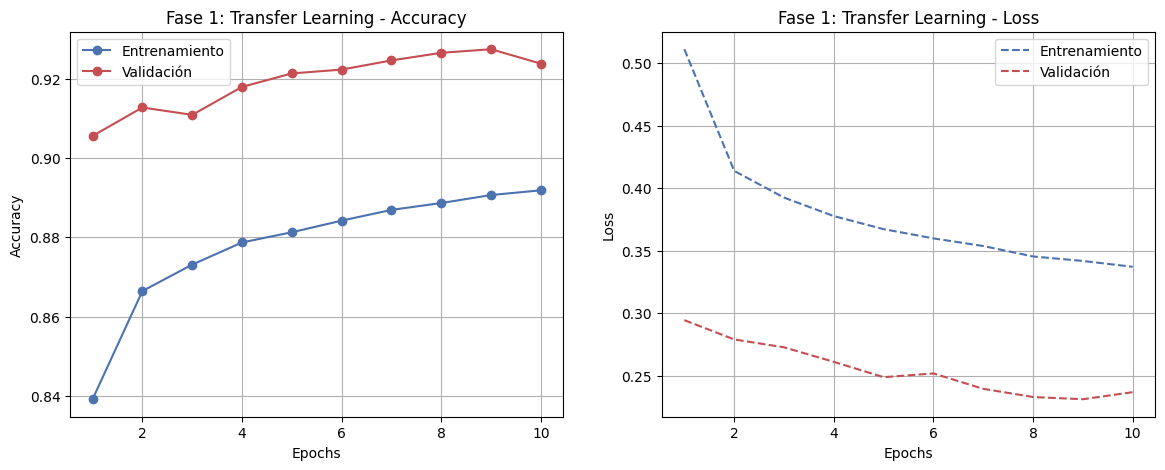

In [36]:
def plot_history(history, title="Progreso del Entrenamiento"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Gráfica de Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
    plt.plot(epochs, val_acc, 'ro-', label='Validación')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Gráfica de Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b--', label='Entrenamiento')
    plt.plot(epochs, val_loss, 'r--', label='Validación')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()

# Ejecutar visualización (solo funcionará cuando model.fit haya terminado)
if 'history_phase1' in locals():
    plot_history(history_phase1, title="Fase 1: Transfer Learning")
else:
    print("⏳ Espera a que termine el entrenamiento para ver las gráficas.")

## 🔥 6. Fase 2: Fine-tuning (descongelar capas)

In [37]:
# 1. Descongelar el modelo base (EfficientNet)
base_model.trainable = True

# 2. Configurar profundidad del Fine-Tuning
# RTX 3080, '30' es poco. Subimos a '100' para mejor precisión.
fine_tune_at = 100

# Congelar todas las capas ANTES de las últimas 100
for layer in base_model.layers[:-fine_tune_at]:
    layer.trainable = False

# 3. Prints Corregidos (Consultamos a base_model, no a model)
print(f"Estadísticas del Fine-Tuning:")
print(f"  - Total capas en EfficientNet: {len(base_model.layers)}")
print(f"  - Capas que se entrenarán (reales): {fine_tune_at}")
print(f"  - Capas congeladas: {len(base_model.layers) - fine_tune_at}")

Estadísticas del Fine-Tuning:
  - Total capas en EfficientNet: 239
  - Capas que se entrenarán (reales): 100
  - Capas congeladas: 139


In [38]:
# Usamos un Learning Rate MUY BAJO (1e-5) para pulir los pesos sin romper lo aprendido.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
)

# 4. Callbacks para Fase 2 (Más paciencia)
callbacks_phase2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,             # Paciencia media para fine-tuning
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,             # Reducción agresiva si se estanca
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\n🚀 Configuración de Fase 2 lista.")
print(f"   - Learning Rate: 1e-5 (Lento y preciso)")
print(f"   - Callbacks: EarlyStopping (7), ReduceLROnPlateau (3)")


🚀 Configuración de Fase 2 lista.
   - Learning Rate: 1e-5 (Lento y preciso)
   - Callbacks: EarlyStopping (7), ReduceLROnPlateau (3)


In [39]:
print(f"🚀 Iniciando Fase 2: Fine-Tuning en RTX 3080...")
print("   (Esto puede tardar unos minutos, monitoriza la temperatura de tu GPU)")

# 1. ENTRENAMIENTO

history_phase2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=15,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks_phase2,
    verbose=1
)

🚀 Iniciando Fase 2: Fine-Tuning en RTX 3080...
   (Esto puede tardar unos minutos, monitoriza la temperatura de tu GPU)
Epoch 1/15
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.8222 - loss: 0.5529 - top_3_accuracy: 0.9548
Epoch 1: val_accuracy improved from None to 0.92287, saving model to best_model_final.keras

Epoch 1: finished saving model to best_model_final.keras
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 1593s 564ms/step - accuracy: 0.8510 - loss: 0.4635 - top_3_accuracy: 0.9667 - val_accuracy: 0.9229 - val_loss: 0.2448 - val_top_3_accuracy: 0.9879 - learning_rate: 1.0000e-05
Epoch 2/15
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8863 - loss: 0.3559 - top_3_accuracy: 0.9789
Epoch 2: val_accuracy improved from 0.92287 to 0.93053, saving model to best_model_final.keras

Epoch 2: finished saving model to best_model_final.keras
2745/2745 ━━━━━━━━━━━━━━━━━━━━ 1489s 543ms/step - accuracy: 0.8892 - loss: 0.3475 - top_3_accuracy: 0.9794 - val_accuracy: 0.9305 - val_loss:

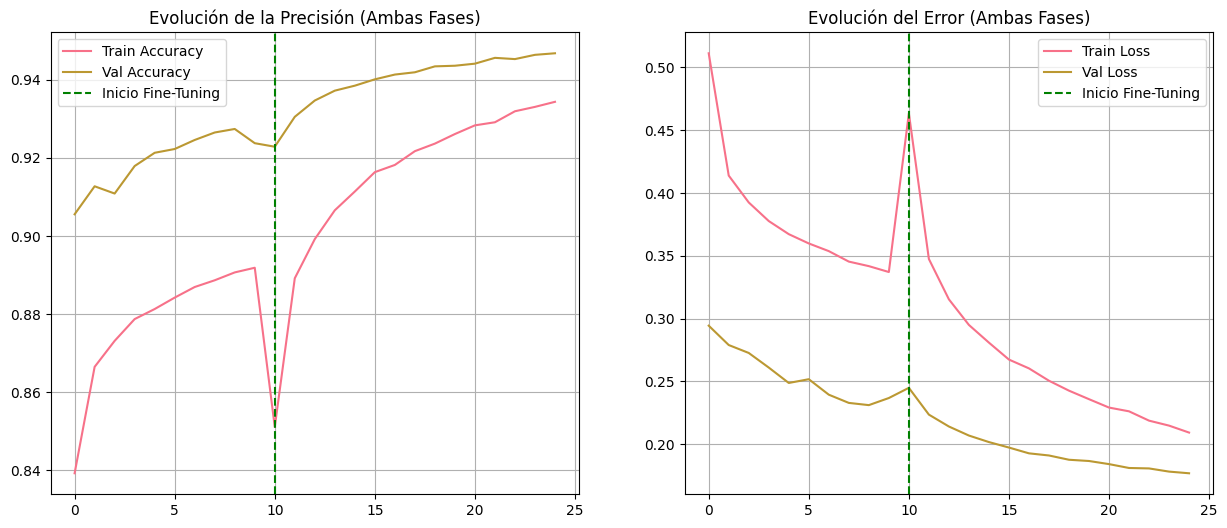

📊 Gráficas generadas: La línea verde marca cuando descongelamos las 100 capas.


In [40]:
# 2. VISUALIZACIÓN INMEDIATA DEL PROGRESO

def plot_phase2_history(h1, h2):
    """Combina y grafica la historia de ambas fases"""
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    plt.figure(figsize=(15, 6))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.axvline(x=len(h1.history['accuracy']), color='green', linestyle='--', label='Inicio Fine-Tuning')
    plt.title('Evolución de la Precisión (Ambas Fases)')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.axvline(x=len(h1.history['loss']), color='green', linestyle='--', label='Inicio Fine-Tuning')
    plt.title('Evolución del Error (Ambas Fases)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Intentar graficar todo junto si existe history_phase1
if 'history_phase1' in locals():
    try:
        plot_phase2_history(history_phase1, history_phase2)
        print("📊 Gráficas generadas: La línea verde marca cuando descongelamos las 100 capas.")
    except Exception as e:
        print(f"No se pudieron combinar las gráficas (quizás se reinició el kernel): {e}")
        # Fallback: graficar solo fase 2
        plot_history(history_phase2, title="Fase 2: Fine-Tuning")
else:
    plot_history(history_phase2, title="Fase 2: Fine-Tuning")

## 📈 7. Visualización del entrenamiento

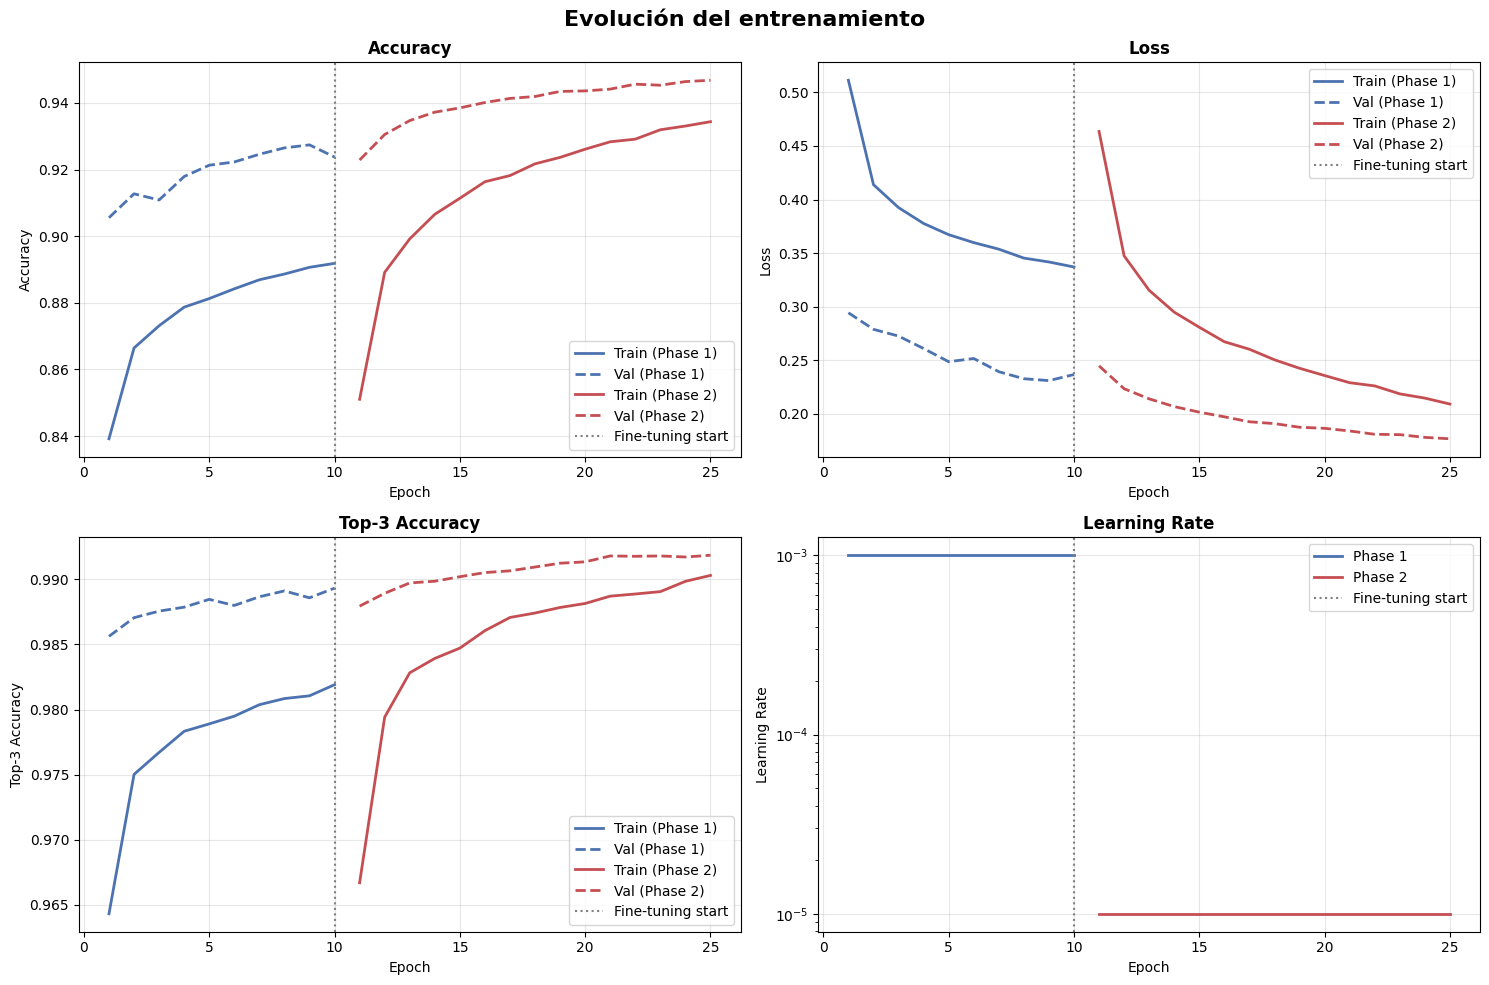

In [41]:
# Combinar historiales
def plot_training_history(history1, history2):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Evolución del entrenamiento', fontsize=16, fontweight='bold')
    
    # Combinar historiales
    epochs1 = range(1, len(history1.history['accuracy']) + 1)
    epochs2 = range(len(history1.history['accuracy']) + 1, 
                   len(history1.history['accuracy']) + len(history2.history['accuracy']) + 1)
    
    # Accuracy
    axes[0, 0].plot(epochs1, history1.history['accuracy'], 'b-', label='Train (Phase 1)', linewidth=2)
    axes[0, 0].plot(epochs1, history1.history['val_accuracy'], 'b--', label='Val (Phase 1)', linewidth=2)
    axes[0, 0].plot(epochs2, history2.history['accuracy'], 'r-', label='Train (Phase 2)', linewidth=2)
    axes[0, 0].plot(epochs2, history2.history['val_accuracy'], 'r--', label='Val (Phase 2)', linewidth=2)
    axes[0, 0].axvline(len(epochs1), color='gray', linestyle=':', label='Fine-tuning start')
    axes[0, 0].set_title('Accuracy', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Loss
    axes[0, 1].plot(epochs1, history1.history['loss'], 'b-', label='Train (Phase 1)', linewidth=2)
    axes[0, 1].plot(epochs1, history1.history['val_loss'], 'b--', label='Val (Phase 1)', linewidth=2)
    axes[0, 1].plot(epochs2, history2.history['loss'], 'r-', label='Train (Phase 2)', linewidth=2)
    axes[0, 1].plot(epochs2, history2.history['val_loss'], 'r--', label='Val (Phase 2)', linewidth=2)
    axes[0, 1].axvline(len(epochs1), color='gray', linestyle=':', label='Fine-tuning start')
    axes[0, 1].set_title('Loss', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Top-3 Accuracy
    axes[1, 0].plot(epochs1, history1.history['top_3_accuracy'], 'b-', label='Train (Phase 1)', linewidth=2)
    axes[1, 0].plot(epochs1, history1.history['val_top_3_accuracy'], 'b--', label='Val (Phase 1)', linewidth=2)
    axes[1, 0].plot(epochs2, history2.history['top_3_accuracy'], 'r-', label='Train (Phase 2)', linewidth=2)
    axes[1, 0].plot(epochs2, history2.history['val_top_3_accuracy'], 'r--', label='Val (Phase 2)', linewidth=2)
    axes[1, 0].axvline(len(epochs1), color='gray', linestyle=':', label='Fine-tuning start')
    axes[1, 0].set_title('Top-3 Accuracy', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Top-3 Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Learning Rate
    lr1 = history1.history.get('lr', [1e-3] * len(epochs1))
    lr2 = history2.history.get('lr', [1e-5] * len(epochs2))
    axes[1, 1].plot(epochs1, lr1, 'b-', label='Phase 1', linewidth=2)
    axes[1, 1].plot(epochs2, lr2, 'r-', label='Phase 2', linewidth=2)
    axes[1, 1].axvline(len(epochs1), color='gray', linestyle=':', label='Fine-tuning start')
    axes[1, 1].set_title('Learning Rate', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history_phase1, history_phase2)

## 🎯 8. Evaluación en test set

In [42]:
# 1. Cargar el MEJOR modelo guardado
# Usamos compile=False y compilamos manualmente después para evitar warnings de Mixed Precision,
# aunque cargarlo normal suele funcionar, esto es más seguro.
print("📂 Cargando 'best_model_final.keras'...")
try:
    best_model = tf.keras.models.load_model('best_model_final.keras')
    print("✓ Modelo cargado exitosamente.")
except OSError:
    print("❌ No se encontró el archivo 'best_model_final.keras'.")
    print("   Asegúrate de que el entrenamiento anterior (Fase 2) terminó y guardó el checkpoint.")
    # Si falla, podrías intentar cargar 'best_model_phase1.keras' como fallback

# 2. Evaluar en test
if 'best_model' in locals():
    print("\n🔍 Evaluando modelo en test set (esto puede tardar unos segundos)...")
    
    # Asegurarnos de que test_gen existe (por si se reinició el kernel)
    if 'test_gen' not in locals():
        print("⚠️ Generando test_gen de nuevo...")
        # Re-creamos el generador si no existe (usando BATCH_SIZE definido anteriormente)
        test_gen = data_generator(df, test_idx, BATCH_SIZE, num_classes, shuffle=False, augment=False)
        test_steps = len(test_idx) // BATCH_SIZE

    test_loss, test_acc, test_top3 = best_model.evaluate(
        test_gen, 
        steps=test_steps,
        verbose=1
    )

    print(f"\n{'='*60}")
    print(f"📊 RESULTADOS FINALES EN TEST SET")
    print(f"{'='*60}")
    print(f"  Test Accuracy:     {test_acc:.2%}")
    print(f"  Test Top-3 Acc:    {test_top3:.2%}")
    print(f"  Test Loss:         {test_loss:.4f}")
    print(f"{'='*60}")

📂 Cargando 'best_model_final.keras'...
✓ Modelo cargado exitosamente.

🔍 Evaluando modelo en test set (esto puede tardar unos segundos)...
588/588 ━━━━━━━━━━━━━━━━━━━━ 133s 210ms/step - accuracy: 0.9465 - loss: 0.1786 - top_3_accuracy: 0.9918

📊 RESULTADOS FINALES EN TEST SET
  Test Accuracy:     94.65%
  Test Top-3 Acc:    99.18%
  Test Loss:         0.1786


## 📊 9. Métricas detalladas y Confusion Matrix

In [43]:
from tqdm import tqdm # Librería para barra de progreso

# Generar predicciones
print(f"🔄 Generando predicciones para {len(test_idx)} imágenes...")

# Importante: shuffle=False para que las predicciones coincidan con las etiquetas reales en orden
test_gen_eval = data_generator(df, test_idx, BATCH_SIZE, num_classes, shuffle=False, augment=False)

y_true = []
y_pred = []

# Usamos tqdm para ver el avance
for _ in tqdm(range(test_steps), desc="Procesando lotes"):
    # Obtenemos el siguiente lote del generador
    X_batch, y_batch = next(test_gen_eval)
    
    # Predicción rápida en GPU
    predictions = best_model.predict(X_batch, verbose=0)
    
    # Guardamos los índices de la clase ganadora (argmax)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"✓ {len(y_true)} predicciones generadas y listas para evaluar.")

🔄 Generando predicciones para 37652 imágenes...


Procesando lotes: 100%|██████████| 588/588 [03:17<00:00,  2.98it/s]

✓ 37632 predicciones generadas y listas para evaluar.


In [44]:

# Classification Report
# Comparará tus predicciones (y_pred) con la realidad (y_true)
print(f"\n📋 CLASSIFICATION REPORT (Modelo Final)\n")

# label_encoder.classes_ contiene los nombres ["bag", "dress", "shoes"...]
print(classification_report(
    y_true, 
    y_pred, 
    target_names=label_encoder.classes_,
    digits=3
))


📋 CLASSIFICATION REPORT (Modelo Final)

              precision    recall  f1-score   support

 accessories      0.836     0.720     0.774      1044
    all-body      0.902     0.868     0.885      2770
        bags      0.966     0.985     0.975      6104
     bottoms      0.977     0.967     0.972      4148
        hats      0.968     0.951     0.959       910
   jewellery      0.957     0.975     0.966      6210
   outerwear      0.893     0.905     0.899      2560
     scarves      0.834     0.728     0.777       734
       shoes      0.992     0.991     0.992      6723
  sunglasses      0.988     0.987     0.988      1481
        tops      0.893     0.919     0.906      4948

    accuracy                          0.947     37632
   macro avg      0.928     0.909     0.917     37632
weighted avg      0.946     0.947     0.946     37632



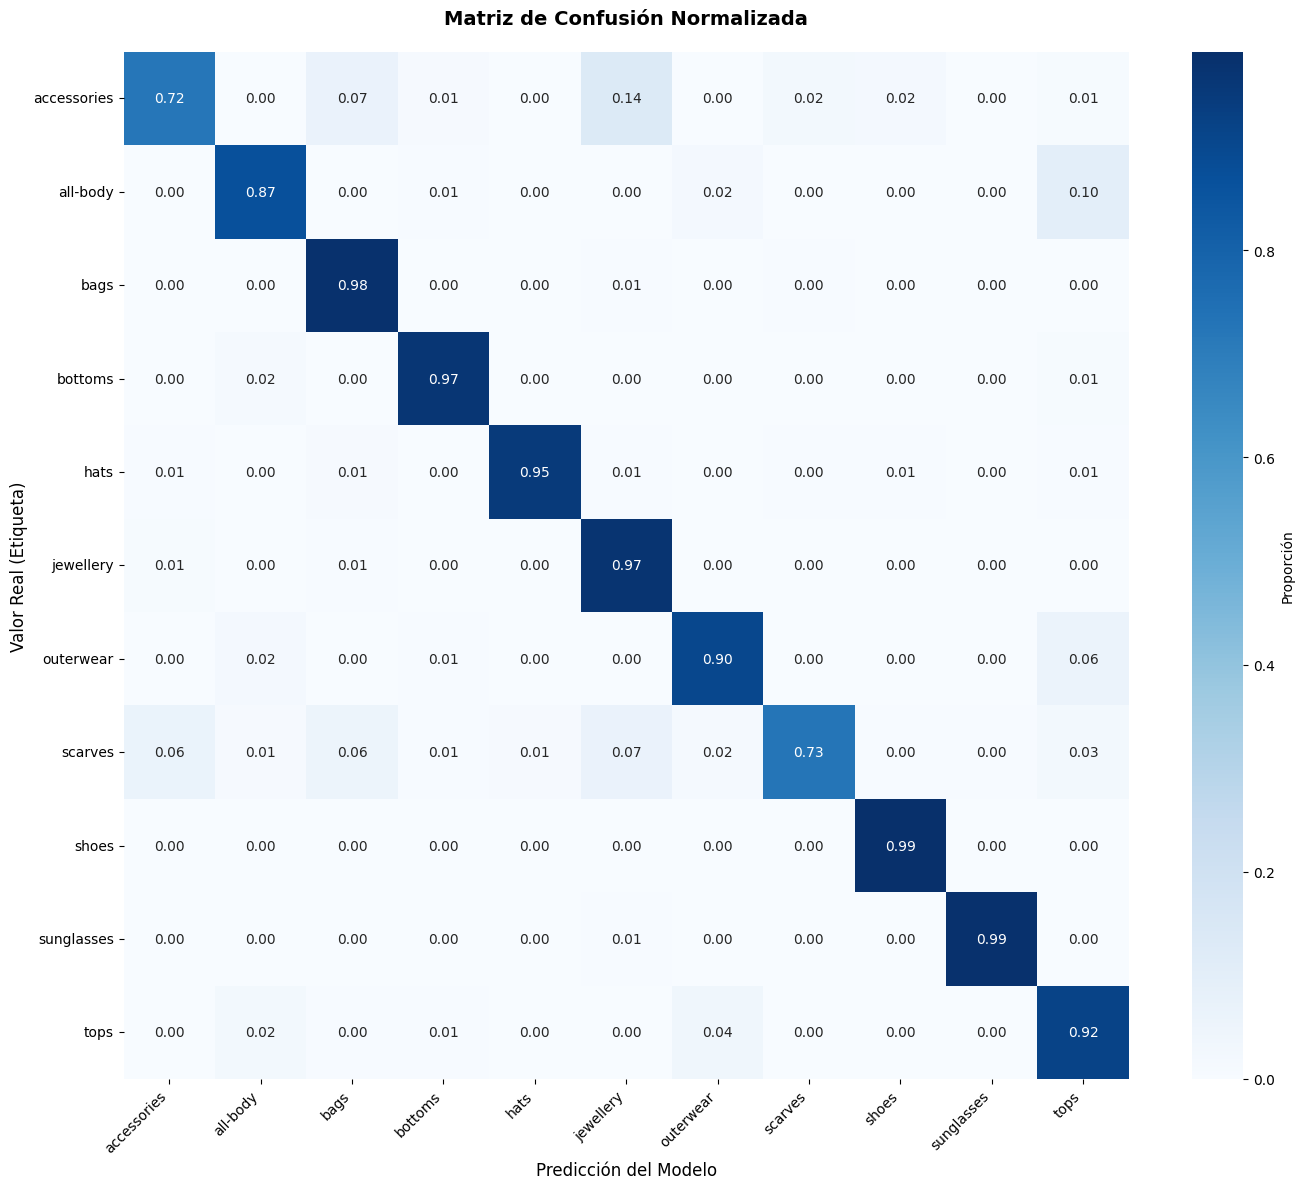

In [45]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Normalizar para ver proporciones (0 a 1) en lugar de números brutos
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Configuración visual
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_normalized,
    annot=True,              # Mostrar los números en cada celda
    fmt='.2f',               # Dos decimales
    cmap='Blues',            # Escala de azules
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Proporción'}
)

plt.title('Matriz de Confusión Normalizada', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Etiqueta)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar la imagen en alta resolución
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 🔍 10. Análisis de predicciones

In [46]:
# Predicciones aleatorias con confianza
def show_predictions(n_samples=20):
    # Seleccionar índices aleatorios del conjunto de prueba
    indices_aleatorios = np.random.choice(test_idx, n_samples, replace=False)
    
    print(f"\n{'='*100}")
    print(f"{'ANÁLISIS DE PREDICCIONES ALEATORIAS':^100}")
    print(f"{'='*100}\n")
    
    correctas = 0
    
    for i, idx in enumerate(indices_aleatorios, 1):
        sample = df.iloc[idx]
        
        # --- PROCESAMIENTO AL VUELO (Obligatorio para evitar error de RAM) ---
        # 1. Convertir imagen cruda a array RGB
        img = to_rgb_uint8(sample['image'])
        # 2. Redimensionar y normalizar
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = img / 255.0
        # 3. Expandir dimensiones para el modelo (Batch de 1)
        img_array = np.expand_dims(img, axis=0)
        
        # Predecir usando la GPU
        prediction = best_model.predict(img_array, verbose=0)
        
        # Top 3 predicciones
        top3_idx = np.argsort(prediction[0])[-3:][::-1]
        top3_probs = prediction[0][top3_idx]
        top3_labels = label_encoder.inverse_transform(top3_idx)
        
        # Etiquetas
        true_label = label_encoder.inverse_transform([sample['category_encoded']])[0]
        pred_label = top3_labels[0]
        
        es_correcto = pred_label == true_label
        if es_correcto:
            correctas += 1
        
        simbolo = '✓' if es_correcto else '✗'
        
        print(f"{i:2}. {simbolo} Real: {true_label:20} | Top-3 predicciones:")
        for j, (label, prob) in enumerate(zip(top3_labels, top3_probs), 1):
            print(f"      {j}. {label:20} ({prob:6.2%})")
        print()
    
    print(f"{'='*100}")
    print(f"Accuracy en estas {n_samples} muestras: {correctas}/{n_samples} = {correctas/n_samples:.1%}")
    print(f"{'='*100}\n")

# Ejecutar con 20 muestras
show_predictions(20)


                                ANÁLISIS DE PREDICCIONES ALEATORIAS                                 

 1. ✓ Real: tops                 | Top-3 predicciones:
      1. tops                 (93.07%)
      2. outerwear            ( 6.46%)
      3. all-body             ( 0.39%)

 2. ✓ Real: tops                 | Top-3 predicciones:
      1. tops                 (98.66%)
      2. all-body             ( 1.21%)
      3. bottoms              ( 0.10%)

 3. ✓ Real: bags                 | Top-3 predicciones:
      1. bags                 (100.00%)
      2. accessories          ( 0.00%)
      3. jewellery            ( 0.00%)

 4. ✓ Real: shoes                | Top-3 predicciones:
      1. shoes                (100.00%)
      2. tops                 ( 0.00%)
      3. scarves              ( 0.00%)

 5. ✓ Real: tops                 | Top-3 predicciones:
      1. tops                 (96.03%)
      2. outerwear            ( 3.37%)
      3. scarves              ( 0.27%)

 6. ✓ Real: shoes             

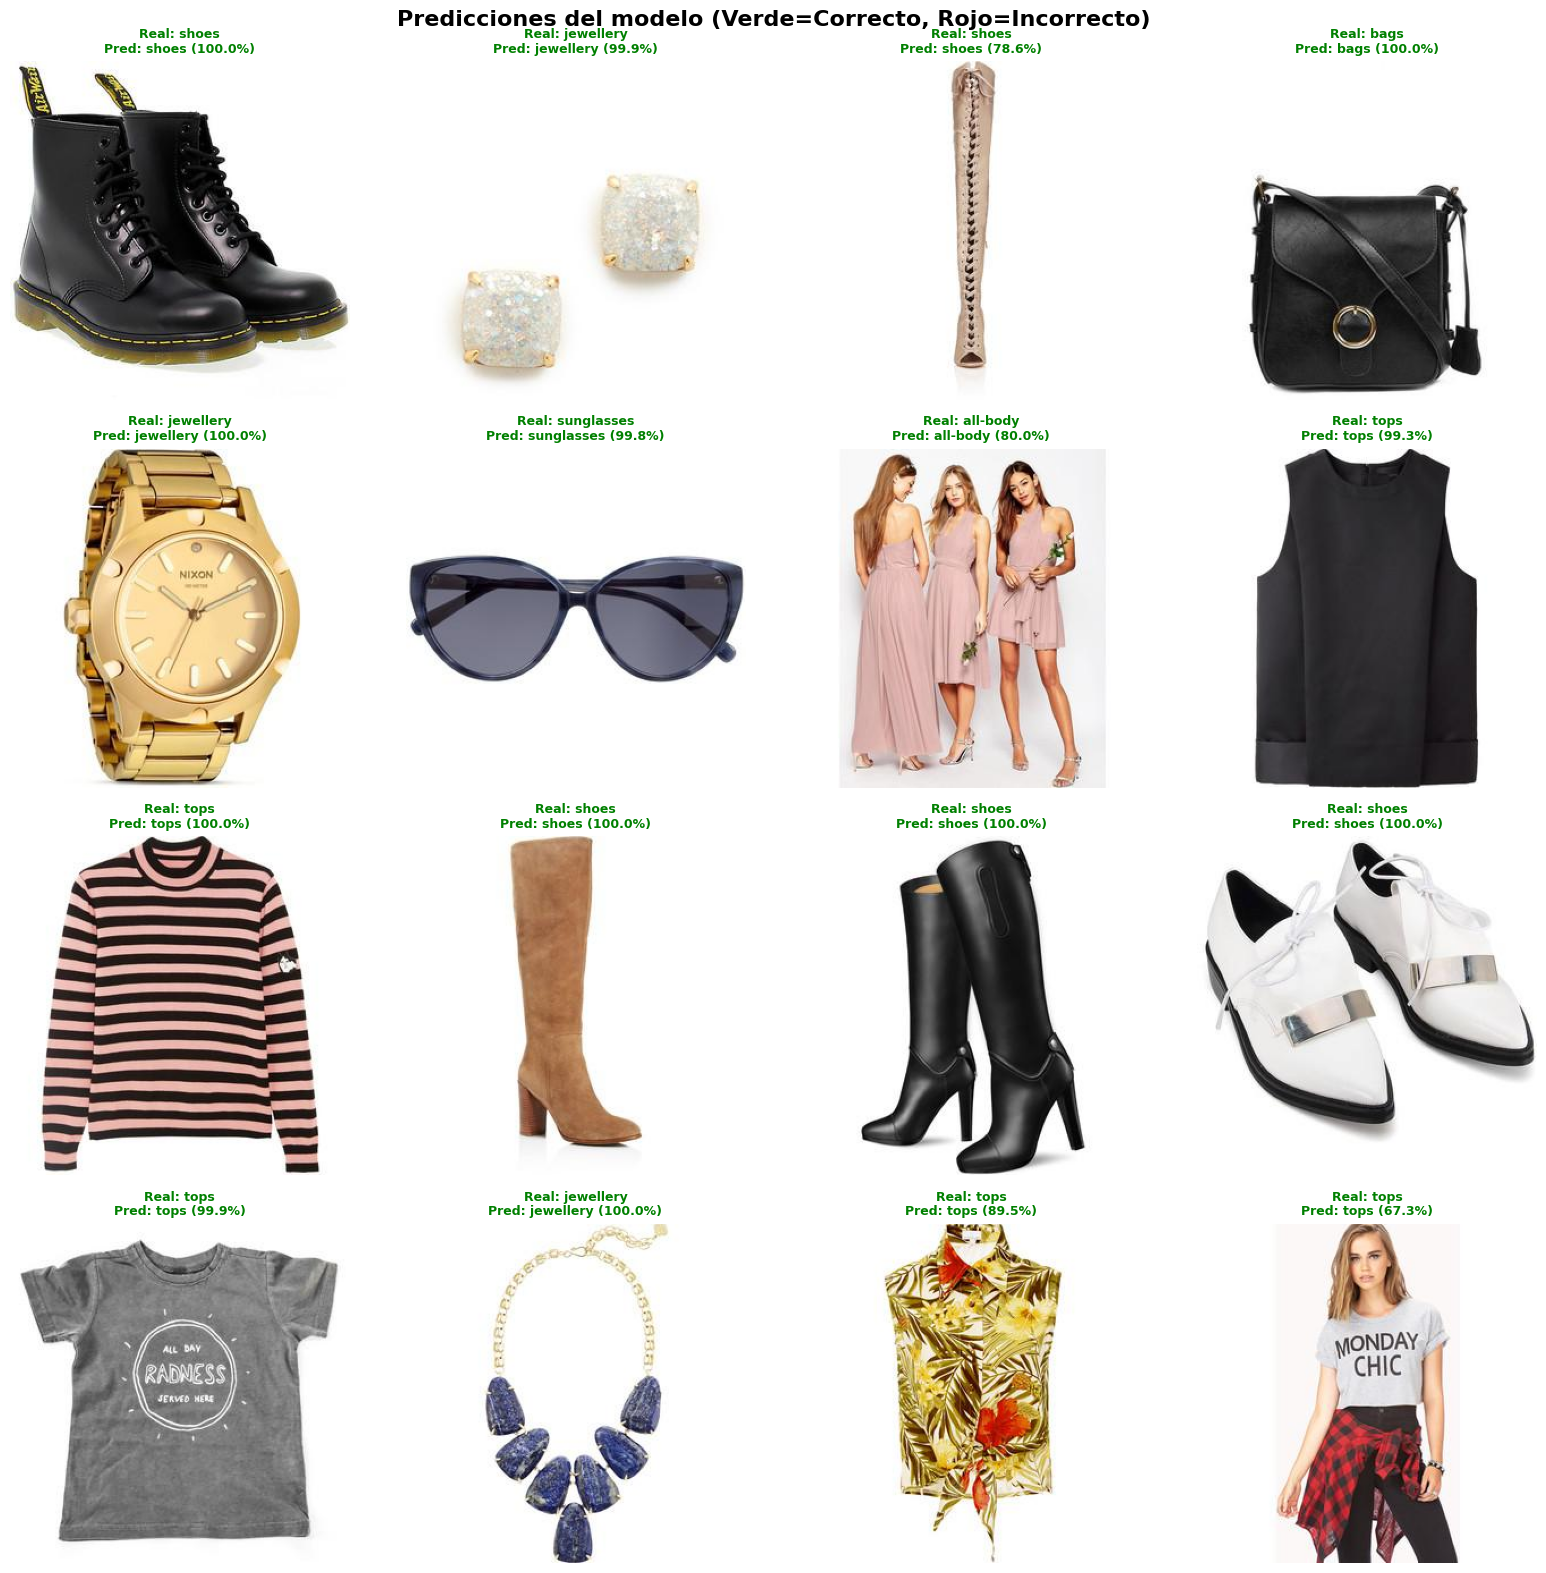

In [47]:
# Visualizar predicciones (correctas e incorrectas)
def visualize_predictions():
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    fig.suptitle('Predicciones del modelo (Verde=Correcto, Rojo=Incorrecto)', 
                 fontsize=16, fontweight='bold')
    
    # Seleccionamos 16 imágenes al azar del test set
    indices_random = np.random.choice(test_idx, 16, replace=False)
    
    for idx, ax in zip(indices_random, axes.flat):
        sample = df.iloc[idx]
        
        # --- PROCESAMIENTO AL VUELO ---
        # 1. Convertir a array usando nuestra función robusta
        img_raw = to_rgb_uint8(sample['image'])
        
        # 2. Preparar para el modelo (Resize + Normalización)
        img_resized = tf.image.resize(img_raw, [IMG_SIZE, IMG_SIZE])
        img_normalized = img_resized / 255.0
        img_batch = np.expand_dims(img_normalized, axis=0)
        
        # 3. Predecir en GPU
        prediction = best_model.predict(img_batch, verbose=0)
        
        pred_idx = np.argmax(prediction[0])
        confidence = prediction[0][pred_idx]
        
        # 4. Decodificar etiquetas
        true_label = label_encoder.inverse_transform([sample['category_encoded']])[0]
        pred_label = label_encoder.inverse_transform([pred_idx])[0]
        
        # --- VISUALIZACIÓN ---
        # Mostramos la imagen original (img_raw) para que se vea con calidad
        ax.imshow(img_raw)
        
        # Color verde si acertó, rojo si falló
        color = 'green' if pred_label == true_label else 'red'
        
        title = f"Real: {true_label}\nPred: {pred_label} ({confidence:.1%})"
        ax.set_title(title, fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    # Guardamos el resultado en disco
    plt.savefig('predictions_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

# Ejecutar la visualización
visualize_predictions()

## 💾 11. Guardar modelo y artefactos

In [48]:
import json

# 1. Guardar el modelo final entrenado
# Este archivo incluye la arquitectura y los pesos afinados
best_model.save('fashion_classifier_final.keras')
print("✓ Modelo guardado: fashion_classifier_final.keras")

# 2. Guardar el label encoder
# Es vital para poder traducir los números (0, 1, 2...) de nuevo a texto en el futuro
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✓ Label encoder guardado: label_encoder.pkl")

# 3. Guardar métricas del proyecto
# Útil para llevar un registro del rendimiento sin tener que cargar el modelo
metrics = {
    'test_accuracy': float(test_acc),
    'test_top3_accuracy': float(test_top3),
    'test_loss': float(test_loss),
    'num_classes': int(num_classes),
    'img_size': IMG_SIZE,
    'categories': label_encoder.classes_.tolist()
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✓ Métricas guardadas: model_metrics.json")

print("\n✅ Todos los artefactos guardados exitosamente en tu almacenamiento local.")

✓ Modelo guardado: fashion_classifier_final.keras
✓ Label encoder guardado: label_encoder.pkl
✓ Métricas guardadas: model_metrics.json

✅ Todos los artefactos guardados exitosamente en tu almacenamiento local.


## 🚀 12. Función de inferencia para nuevas imágenes

In [49]:
def predict_image(image_path_or_pil, model, label_encoder, img_size=224, top_k=3):
    """
    Función de inferencia optimizada para producción.
    """
    # 1. Carga de imagen
    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil)
    else:
        img = image_path_or_pil

    # 2. Preprocesamiento robusto (mismo que en el entrenamiento)
    # Convertimos a RGB uint8 primero
    img_array = to_rgb_uint8(img)
    
    # Redimensionamos y normalizamos a [0, 1]
    img_resized = tf.image.resize(img_array, [img_size, img_size])
    img_normalized = img_resized / 255.0
    
    # Añadimos dimensión de batch (1, 224, 224, 3)
    img_final = np.expand_dims(img_normalized, axis=0)
    
    # 3. Predicción en GPU
    predictions = model.predict(img_final, verbose=0)[0]
    
    # 4. Obtener el Top-K
    top_indices = np.argsort(predictions)[-top_k:][::-1]
    top_probs = predictions[top_indices]
    top_labels = label_encoder.inverse_transform(top_indices)
    
    return {
        'top_prediction': top_labels[0],
        'confidence': float(top_probs[0]),
        'top_k_predictions': [
            {'category': label, 'confidence': float(prob)}
            for label, prob in zip(top_labels, top_probs)
        ]
    }

# --- EJEMPLO DE USO REAL ---
print("\n🔍 Probando inferencia con una muestra aleatoria...")

# Seleccionamos una imagen del test set que el modelo no ha usado para entrenar
sample = df.iloc[np.random.choice(test_idx)]

# Ejecutamos la predicción
result = predict_image(sample['image'], best_model, label_encoder)

print(f"\n✅ RESULTADO:")
print(f"{'='*30}")
print(f"REAL:       {sample['category']}")
print(f"PREDICCIÓN: {result['top_prediction']} ({result['confidence']:.1%})")
print(f"{'='*30}")
print(f"\nTop-{len(result['top_k_predictions'])} alternativas:")
for i, p in enumerate(result['top_k_predictions'], 1):
    print(f"  {i}. {p['category']:20} {p['confidence']:.2%}")


🔍 Probando inferencia con una muestra aleatoria...

✅ RESULTADO:
REAL:       jewellery
PREDICCIÓN: jewellery (99.6%)

Top-3 alternativas:
  1. jewellery            99.62%
  2. accessories          0.36%
  3. scarves              0.01%


## 📝 13. Resumen final

In [50]:
# --- 13. RESUMEN FINAL DEL PROYECTO ---

print("\n" + "="*80)
print(" " * 20 + "🎉 RESUMEN DEL PROYECTO FINALIZADO 🎉")
print("="*80)

# Información del Dataset
print(f"\n📊 DATASET:")
print(f"   - Nombre: Polyvore Fashion Dataset")
print(f"   - Total de imágenes procesadas: {len(df):,}")
print(f"   - Número de categorías de moda: {num_classes}")
print(f"   - Split: {len(train_idx):,} train / {len(val_idx):,} val / {len(test_idx):,} test")

# Detalles del Modelo y Hardware
print(f"\n🧠 ARQUITECTURA Y HARDWARE:")
print(f"   - Modelo Base: EfficientNetB0 (Pre-entrenado en ImageNet)")
print(f"   - Entrenamiento: Transfer Learning + Fine-tuning (100 capas)")
print(f"   - Optimizaciones: Mixed Precision (FP16) + GPU RTX 3080")
print(f"   - Parámetros totales: {best_model.count_params():,}")
print(f"   - Data Augmentation: Activo (rotación, zoom, giros)")

# Resultados obtenidos en Test
if 'test_acc' in locals():
    print(f"\n🎯 RESULTADOS FINALES (TEST SET):")
    print(f"   - Accuracy (Top-1):    {test_acc:.2%}")
    print(f"   - Accuracy (Top-3):    {test_top3:.2%}")
    print(f"   - Loss final:          {test_loss:.4f}")

# Registro de archivos
print(f"\n💾 ARTEFACTOS GENERADOS:")
print(f"   - fashion_classifier_final.keras  -> Modelo para producción")
print(f"   - label_encoder.pkl               -> Traductor de categorías")
print(f"   - training_history.png            -> Gráficas de aprendizaje")
print(f"   - confusion_matrix.png            -> Análisis de errores")
print(f"   - predictions_visualization.png   -> Muestras visuales")

print("\n" + "="*80)
print(" " * 25 + "✅ PROYECTO COMPLETADO EXITOSAMENTE")
print("="*80 + "\n")


                    🎉 RESUMEN DEL PROYECTO FINALIZADO 🎉

📊 DATASET:
   - Nombre: Polyvore Fashion Dataset
   - Total de imágenes procesadas: 251,008
   - Número de categorías de moda: 11
   - Split: 175,705 train / 37,651 val / 37,652 test

🧠 ARQUITECTURA Y HARDWARE:
   - Modelo Base: EfficientNetB0 (Pre-entrenado en ImageNet)
   - Entrenamiento: Transfer Learning + Fine-tuning (100 capas)
   - Optimizaciones: Mixed Precision (FP16) + GPU RTX 3080
   - Parámetros totales: 4,846,766
   - Data Augmentation: Activo (rotación, zoom, giros)

🎯 RESULTADOS FINALES (TEST SET):
   - Accuracy (Top-1):    94.65%
   - Accuracy (Top-3):    99.18%
   - Loss final:          0.1786

💾 ARTEFACTOS GENERADOS:
   - fashion_classifier_final.keras  -> Modelo para producción
   - label_encoder.pkl               -> Traductor de categorías
   - training_history.png            -> Gráficas de aprendizaje
   - confusion_matrix.png            -> Análisis de errores
   - predictions_visualization.png   -> Muestras